#Proyecto Python

In [ ]:
Proyecto creado con Python usando Jupyter Notebook para limpieza y extracción de datos del Dataset Kiva Loans. Autores Marco Imouokhome y Noelia Sánchez

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Cargar el dataset de kiva y visualizar los 4 primeros registros de la tabla.
df = pd.read_csv('kiva_loans.csv')
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12.0,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14.0,NaN,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6.0,"user_favorite, user_favorite",female,bullet,2014-01-01
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8.0,NaN,female,irregular,2014-01-01
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16.0,NaN,female,monthly,2014-01-01


In [7]:
# Cambiar el tipo de dato de las variables 'disturbed_time' 'posted_time y 'funded_time' a datatime
datos = ['posted_time', 'disbursed_time', 'funded_time', 'date']
for col in datos:
  df[col] = pd.to_datetime(df[col], errors='coerce')

print('datos convertidos a fecha')
print(df[datos].dtypes)
df.info()


datos convertidos a fecha
posted_time       datetime64[ns, UTC]
disbursed_time    datetime64[ns, UTC]
funded_time       datetime64[ns, UTC]
date                   datetime64[ns]
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185781 entries, 0 to 185780
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  185781 non-null  int64              
 1   funded_amount       185781 non-null  float64            
 2   loan_amount         185781 non-null  float64            
 3   activity            185781 non-null  object             
 4   sector              185781 non-null  object             
 5   use                 183169 non-null  object             
 6   country_code        185781 non-null  object             
 7   country             185781 non-null  object             
 8   region              161455 non-null  object             
 9   currency  

In [8]:
# Chequear valores duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop(columns=['tags'])

In [11]:
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12.0,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14.0,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6.0,female,bullet,2014-01-01
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8.0,female,irregular,2014-01-01
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16.0,female,monthly,2014-01-01


In [13]:
df.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,2612
country_code,0
country,0
region,24326
currency,0


In [16]:
# Tratamos los valores nulos de las variables 'region', 'use' con cadena de texto 'unknown' y la variable 'partner_id con valor numérico (-1)
df['region'] = df['region'].fillna('unknown')
df['use'] = df['use'].fillna('unknown')
df['borrower_genders'] = df['borrower_genders'].fillna('unknown')
df['partner_id'] = df['partner_id'].fillna(-1)
df.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country_code,0
country,0
region,0
currency,0


In [ ]:
# Se eliminan los nulos en las columnas con pocos datos nulos

df = df.dropna(subset=['term_in_months'])
df = df.dropna(subset=['repayment_interval'])
df = df.dropna(subset=['lender_count'])
df = df.dropna(subset=['date'])
df.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country_code,0
country,0
region,0
currency,0


In [ ]:
# Limpieza de texto, mayúsculas, minúsculas en 'country', 'use', 'sector' y 'activity'

df['country'] = df['country'].str.strip().str.lower()
df['sector'] = df['sector'].str.strip().str.lower()
df['activity'] = df['activity'].str.strip().str.lower()
df['use'] = df['use'].str.strip().str.lower()
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12.0,female,irregular,2014-01-01
1,653053,575.0,575.0,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14.0,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6.0,female,bullet,2014-01-01
3,653063,200.0,200.0,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8.0,female,irregular,2014-01-01
4,653084,400.0,400.0,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16.0,female,monthly,2014-01-01


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185780 entries, 0 to 185779
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  185780 non-null  int64              
 1   funded_amount       185780 non-null  float64            
 2   loan_amount         185780 non-null  float64            
 3   activity            185780 non-null  object             
 4   sector              185780 non-null  object             
 5   use                 185780 non-null  object             
 6   country_code        185780 non-null  object             
 7   country             185780 non-null  object             
 8   region              185780 non-null  object             
 9   currency            185780 non-null  object             
 10  partner_id          185780 non-null  float64            
 11  posted_time         185780 non-null  datetime64[ns, UTC]
 12  disbursed_time      1

In [ ]:
# Se convierte el tipo de dato de float a int para facilitar la lectura

df['funded_amount'] = df['funded_amount'].astype(int)
df['loan_amount'] = df['loan_amount'].astype(int)
df['term_in_months'] = df['term_in_months'].astype(int)
df['lender_count'] = df['lender_count'].astype(int)
df['partner_id'] = df['partner_id'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185780 entries, 0 to 185779
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  185780 non-null  int64              
 1   funded_amount       185780 non-null  int64              
 2   loan_amount         185780 non-null  int64              
 3   activity            185780 non-null  object             
 4   sector              185780 non-null  object             
 5   use                 185780 non-null  object             
 6   country_code        185780 non-null  object             
 7   country             185780 non-null  object             
 8   region              185780 non-null  object             
 9   currency            185780 non-null  object             
 10  partner_id          185780 non-null  int64              
 11  posted_time         185780 non-null  datetime64[ns, UTC]
 12  disbursed_time      1

In [ ]:
#Se crea una columna para indicar el número total de prestatarios sin diferencia de género

df['total_borrowers'] = df['borrower_genders'].str.count(',') + 1
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,borrower_genders,repayment_interval,date,total_borrowers
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,247,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12,12,female,irregular,2014-01-01,1
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,247,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11,14,"female, female",irregular,2014-01-01,2
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,334,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43,6,female,bullet,2014-01-01,1
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,247,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11,8,female,irregular,2014-01-01,1
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,245,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14,16,female,monthly,2014-01-01,1


In [ ]:
# Se crea una columna para indicar el número de mujeres y otra para el número de hombres

df['num_female'] = df['borrower_genders'].str.count('female')
df['num_male'] = df['borrower_genders'].str.count('male')
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,disbursed_time,funded_time,term_in_months,lender_count,borrower_genders,repayment_interval,date,total_borrowers,num_female,num_male
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,...,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12,12,female,irregular,2014-01-01,1,1,1
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,...,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11,14,"female, female",irregular,2014-01-01,2,2,2
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,...,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43,6,female,bullet,2014-01-01,1,1,1
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,...,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11,8,female,irregular,2014-01-01,1,1,1
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,...,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14,16,female,monthly,2014-01-01,1,1,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185780 entries, 0 to 185779
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  185780 non-null  int64              
 1   funded_amount       185780 non-null  int64              
 2   loan_amount         185780 non-null  int64              
 3   activity            185780 non-null  object             
 4   sector              185780 non-null  object             
 5   use                 185780 non-null  object             
 6   country_code        185780 non-null  object             
 7   country             185780 non-null  object             
 8   region              185780 non-null  object             
 9   currency            185780 non-null  object             
 10  partner_id          185780 non-null  int64              
 11  posted_time         185780 non-null  datetime64[ns, UTC]
 12  disbursed_time      1

In [ ]:
#Se crea una nueva columna para filtrar por mes y año

df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,term_in_months,lender_count,borrower_genders,repayment_interval,date,total_borrowers,num_female,num_male,month,year
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,...,12,12,female,irregular,2014-01-01,1,1,1,1,2014
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,...,11,14,"female, female",irregular,2014-01-01,2,2,2,1,2014
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,...,43,6,female,bullet,2014-01-01,1,1,1,1,2014
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,...,11,8,female,irregular,2014-01-01,1,1,1,1,2014
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,...,14,16,female,monthly,2014-01-01,1,1,1,1,2014


In [29]:
# Se crea la categoría 'loan_size' para categorizar los préstamos en diferentes rangos por cantidad prestada

def classify_loan(x):
    if x < 500:
        return 'micro'
    elif x < 2000:
        return 'small'
    elif x < 5000:
        return 'medium'
    else:
        return 'large'

df['loan_size'] = df['loan_amount'].apply(classify_loan)

In [30]:
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,lender_count,borrower_genders,repayment_interval,date,total_borrowers,num_female,num_male,month,year,loan_size
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,...,12,female,irregular,2014-01-01,1,1,1,1,2014,micro
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,...,14,"female, female",irregular,2014-01-01,2,2,2,1,2014,small
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,...,6,female,bullet,2014-01-01,1,1,1,1,2014,micro
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,...,8,female,irregular,2014-01-01,1,1,1,1,2014,micro
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,...,16,female,monthly,2014-01-01,1,1,1,1,2014,micro


In [32]:
# Se verifican los resultados

df['loan_size'].value_counts()

,count
loan_size,
micro,85037
small,83462
medium,14109
large,3172


In [34]:
df.head(50)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,lender_count,borrower_genders,repayment_interval,date,total_borrowers,num_female,num_male,month,year,loan_size
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,...,12,female,irregular,2014-01-01,1,1,1,1,2014,micro
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,...,14,"female, female",irregular,2014-01-01,2,2,2,1,2014,small
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,...,6,female,bullet,2014-01-01,1,1,1,1,2014,micro
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,...,8,female,irregular,2014-01-01,1,1,1,1,2014,micro
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,...,16,female,monthly,2014-01-01,1,1,1,1,2014,micro
5,1080148,250,250,services,services,purchase leather for my business using ksh 20000.,KE,kenya,unknown,KES,...,6,female,irregular,2014-01-01,1,1,1,1,2014,micro
6,653067,200,200,dairy,agriculture,to purchase a dairy cow and start a milk produ...,IN,india,Maynaguri,INR,...,8,female,bullet,2014-01-01,1,1,1,1,2014,micro
7,653078,400,400,beauty salon,services,to buy more hair and skin care products.,PK,pakistan,Ellahabad,PKR,...,8,female,monthly,2014-01-01,1,1,1,1,2014,micro
8,653082,475,475,manufacturing,manufacturing,"to purchase leather, plastic soles and heels i...",PK,pakistan,Lahore,PKR,...,19,female,monthly,2014-01-01,1,1,1,1,2014,micro
9,653048,625,625,food production/sales,food,"to buy a stall, gram flour, ketchup, and coal ...",PK,pakistan,Lahore,PKR,...,24,female,irregular,2014-01-01,1,1,1,1,2014,small


In [39]:
# Se agrupan datos para calcular media, suma , y conteo por las variables 'country' y 'loan_amount'

df.groupby('country')['loan_amount'].agg(['mean', 'sum', 'count']).sort_values(by='mean')

,mean,sum,count
country,,,
nigeria,150.674786,457750,3038
liberia,262.712482,540925,2059
madagascar,270.000000,1350,5
philippines,369.690946,14551775,39362
turkey,417.224409,105975,254
...,...,...,...
virgin islands,5000.000000,10000,2
afghanistan,6000.000000,6000,1
congo,6138.942308,638450,104


In [44]:
# Se filtran los préstamos por participacion femenina y su distribución por país

df[df['borrower_genders'] == 'female'] \
  .groupby('country')['loan_amount'] \
  .sum() \
  .sort_values(ascending=False)

,loan_amount
country,
philippines,13312650
kenya,4989050
el salvador,4962275
tajikistan,3630375
united states,3302225
...,...
moldova,3000
solomon islands,2025
somalia,2000


<Axes: >

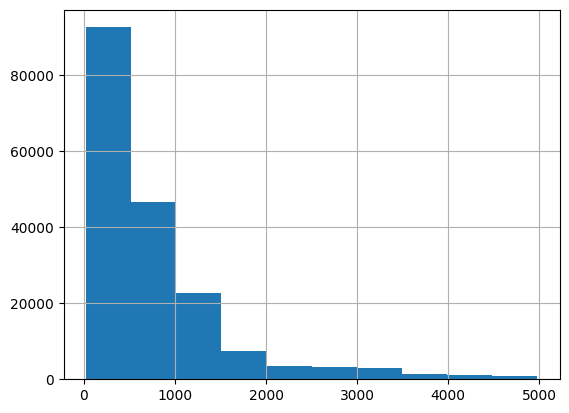

In [45]:
# Se crea un histograma para reconocer outliers visualizando la distribución de los datos

df[df['loan_amount'] < 5000]['loan_amount'].hist()

In [46]:
df.to_csv("kiva_clean_.csv", index=False)

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
df.to_csv('/content/drive/MyDrive/kiva_clean_grupal.csv', index=False)

In [50]:
from google.colab import files
files.download('/content/drive/MyDrive/kiva_clean_grupal.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>